# 🌧️ Dự Báo Lượng Mưa - Đồng Bằng Sông Cửu Long
### Mô hình ARIMA & SARIMA trên 10 trạm đo

**Các bước:**
1. Đọc & xử lý 10 file dữ liệu
2. Phân tích thống kê mô tả & trực quan hoá
3. Kiểm định tính dừng (ADF test)
4. Xây dựng mô hình ARIMA
5. Xây dựng mô hình SARIMA (có tính mùa vụ)
6. Đánh giá & so sánh mô hình
7. Dự báo lượng mưa

## 0. Cài đặt thư viện

In [23]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn pmdarima openpyxl tqdm -q

'pip' is not recognized as an internal or external command,
operable program or batch file.


## 1. Import thư viện

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
import glob
from pathlib import Path
from tqdm import tqdm

# Stats & modelling
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Tất cả thư viện đã sẵn sàng!')

✅ Tất cả thư viện đã sẵn sàng!


## 2. Đọc & xử lý dữ liệu từ 10 file

In [25]:
# ============================================================
# ⚙️  CẤU HÌNH - Chỉnh sửa theo cấu trúc file của bạn
# ============================================================

# Đường dẫn thư mục chứa 10 file (thay đổi theo thực tế)
DATA_DIR = 'C:\đồ án time seri\data'          # hoặc '/content/drive/MyDrive/data' nếu dùng Google Colab

# Pattern tên file (*.csv, *.txt, *.xlsx ...)
FILE_PATTERN = '*.csv'       # Thay đổi nếu file là .txt hoặc .xlsx

# Tên cột trong file gốc
COL_TIME   = 'time'
COL_PRECIP = 'precipitation (mm)'
COL_TEMP   = 'temperature_2m (°C)'
COL_WIND   = 'wind_speed_10m (km/h)'
COL_HUM    = 'relative_humidity_2m (%)'

# Tần suất dữ liệu: 'h' = giờ, 'D' = ngày, 'ME' = tháng
FREQ = 'h'

# Nếu muốn tổng hợp theo ngày trước khi mô hình hoá (khuyến nghị)
RESAMPLE_TO_DAILY = True

# Tỉ lệ train/test
TEST_RATIO = 0.2

# Số bước dự báo
FORECAST_STEPS = 30  # 30 ngày nếu dùng daily

print(f'📁 Thư mục dữ liệu : {DATA_DIR}')
print(f'📋 Pattern file   : {FILE_PATTERN}')
print(f'🔄 Resample daily : {RESAMPLE_TO_DAILY}')

📁 Thư mục dữ liệu : C:\đồ án time seri\data
📋 Pattern file   : *.csv
🔄 Resample daily : True


In [26]:
def load_file(filepath: str) -> pd.DataFrame:
    """Đọc một file dữ liệu khí tượng, hỗ trợ CSV, TSV, TXT, XLSX."""
    ext = Path(filepath).suffix.lower()
    if ext in ['.csv', '.txt']:
        # Thử dấu phân cách tab trước, sau đó dấu phẩy
        try:
            df = pd.read_csv(filepath, sep='\t', encoding='utf-8')
            if df.shape[1] < 2:
                df = pd.read_csv(filepath, sep=',', encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(filepath, sep='\t', encoding='latin-1')
            if df.shape[1] < 2:
                df = pd.read_csv(filepath, sep=',', encoding='latin-1')
        except Exception:
            try:
                df = pd.read_csv(filepath, encoding='utf-8')
            except UnicodeDecodeError:
                df = pd.read_csv(filepath, encoding='latin-1')
    elif ext in ['.xlsx', '.xls']:
        df = pd.read_excel(filepath)
    else:
        raise ValueError(f'Định dạng file không được hỗ trợ: {ext}')

    # Parse cột thời gian
    df[COL_TIME] = pd.to_datetime(df[COL_TIME])
    df = df.set_index(COL_TIME).sort_index()

    # Đổi tên cột về tên ngắn gọn
    rename_map = {
        COL_PRECIP : 'precipitation',
        COL_TEMP   : 'temperature',
        COL_WIND   : 'wind_speed',
        COL_HUM    : 'humidity',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # Chỉ giữ các cột cần thiết
    keep = [c for c in ['precipitation','temperature','wind_speed','humidity'] if c in df.columns]
    return df[keep]


def load_all_files(data_dir: str, pattern: str) -> dict:
    """Đọc tất cả file, trả về dict {station_name: DataFrame}."""
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(
            f'Không tìm thấy file nào với pattern "{pattern}" trong "{data_dir}".\n'
            f'Hãy kiểm tra lại đường dẫn DATA_DIR và FILE_PATTERN.'
        )
    print(f'🔍 Tìm thấy {len(files)} file:')
    stations = {}
    for fp in files:
        name = Path(fp).stem
        df = load_file(fp)
        stations[name] = df
        print(f'   ✔ {name:30s}  shape={df.shape}  '
              f'range=[{df.index.min().date()} → {df.index.max().date()}]')
    return stations


# ── Tải dữ liệu ──────────────────────────────────────────────
stations = load_all_files(DATA_DIR, FILE_PATTERN)
station_names = list(stations.keys())
print(f'\n✅ Đã tải {len(stations)} trạm: {station_names}')

🔍 Tìm thấy 9 file:
   ✔ open-meteo1                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo2                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo3                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo4                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo5                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo6                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo7                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo8                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]
   ✔ open-meteo9                     shape=(87672, 4)  range=[2015-01-01 → 2024-12-31]

✅ Đã tải 9 trạm: ['open-meteo1', 'open-meteo2', 'open-meteo3', 'open-meteo4', 'open-meteo5', 'open-meteo6', 'open-meteo7', 'open-meteo8', 'open-meteo9']


In [27]:
def preprocess(df: pd.DataFrame, resample_daily: bool = True) -> pd.DataFrame:
    """Xử lý missing values, ngoại lệ và resample."""
    df = df.copy()

    # 1. Loại bỏ duplicate index
    df = df[~df.index.duplicated(keep='first')]

    # 2. Tái tạo index liên tục, điền missing
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq=FREQ)
    df = df.reindex(full_idx)

    # 3. Lượng mưa âm → 0
    if 'precipitation' in df.columns:
        df['precipitation'] = df['precipitation'].clip(lower=0)

    # 4. Nội suy tuyến tính cho missing (tối đa 3 giờ liên tiếp)
    df = df.interpolate(method='time', limit=3).fillna(method='ffill').fillna(method='bfill')

    # 5. Resample sang ngày
    if resample_daily:
        agg = {'precipitation': 'sum'}  # tổng mưa ngày
        for col in ['temperature', 'wind_speed', 'humidity']:
            if col in df.columns:
                agg[col] = 'mean'
        df = df.resample('D').agg(agg)

    return df


# Xử lý tất cả trạm
stations_clean = {}
for name, df in stations.items():
    stations_clean[name] = preprocess(df, RESAMPLE_TO_DAILY)

# Kiểm tra nhanh
sample_name = station_names[0]
print(f'\n📊 Mẫu dữ liệu đã xử lý - Trạm: {sample_name}')
display(stations_clean[sample_name].head(10))
print(f'Missing values:\n{stations_clean[sample_name].isnull().sum()}')


📊 Mẫu dữ liệu đã xử lý - Trạm: open-meteo1


,precipitation,temperature,wind_speed,humidity
2015-01-01,0.2,24.754167,7.366667,80.250000
2015-01-02,0.0,24.808333,5.625000,80.750000
2015-01-03,0.6,24.579167,6.491667,81.333333
2015-01-04,1.0,24.925000,3.212500,87.083333
2015-01-05,9.9,24.987500,5.179167,90.791667
2015-01-06,10.7,25.004167,6.358333,90.166667
2015-01-07,0.6,25.420833,11.379167,83.666667
2015-01-08,1.0,25.741667,15.337500,78.458333
2015-01-09,0.0,25.679167,14.995833,73.291667
2015-01-10,0.0,25.583333,11.475000,77.166667


Missing values:
precipitation    0
temperature      0
wind_speed       0
humidity         0
dtype: int64


## 3. Phân tích khám phá (EDA)

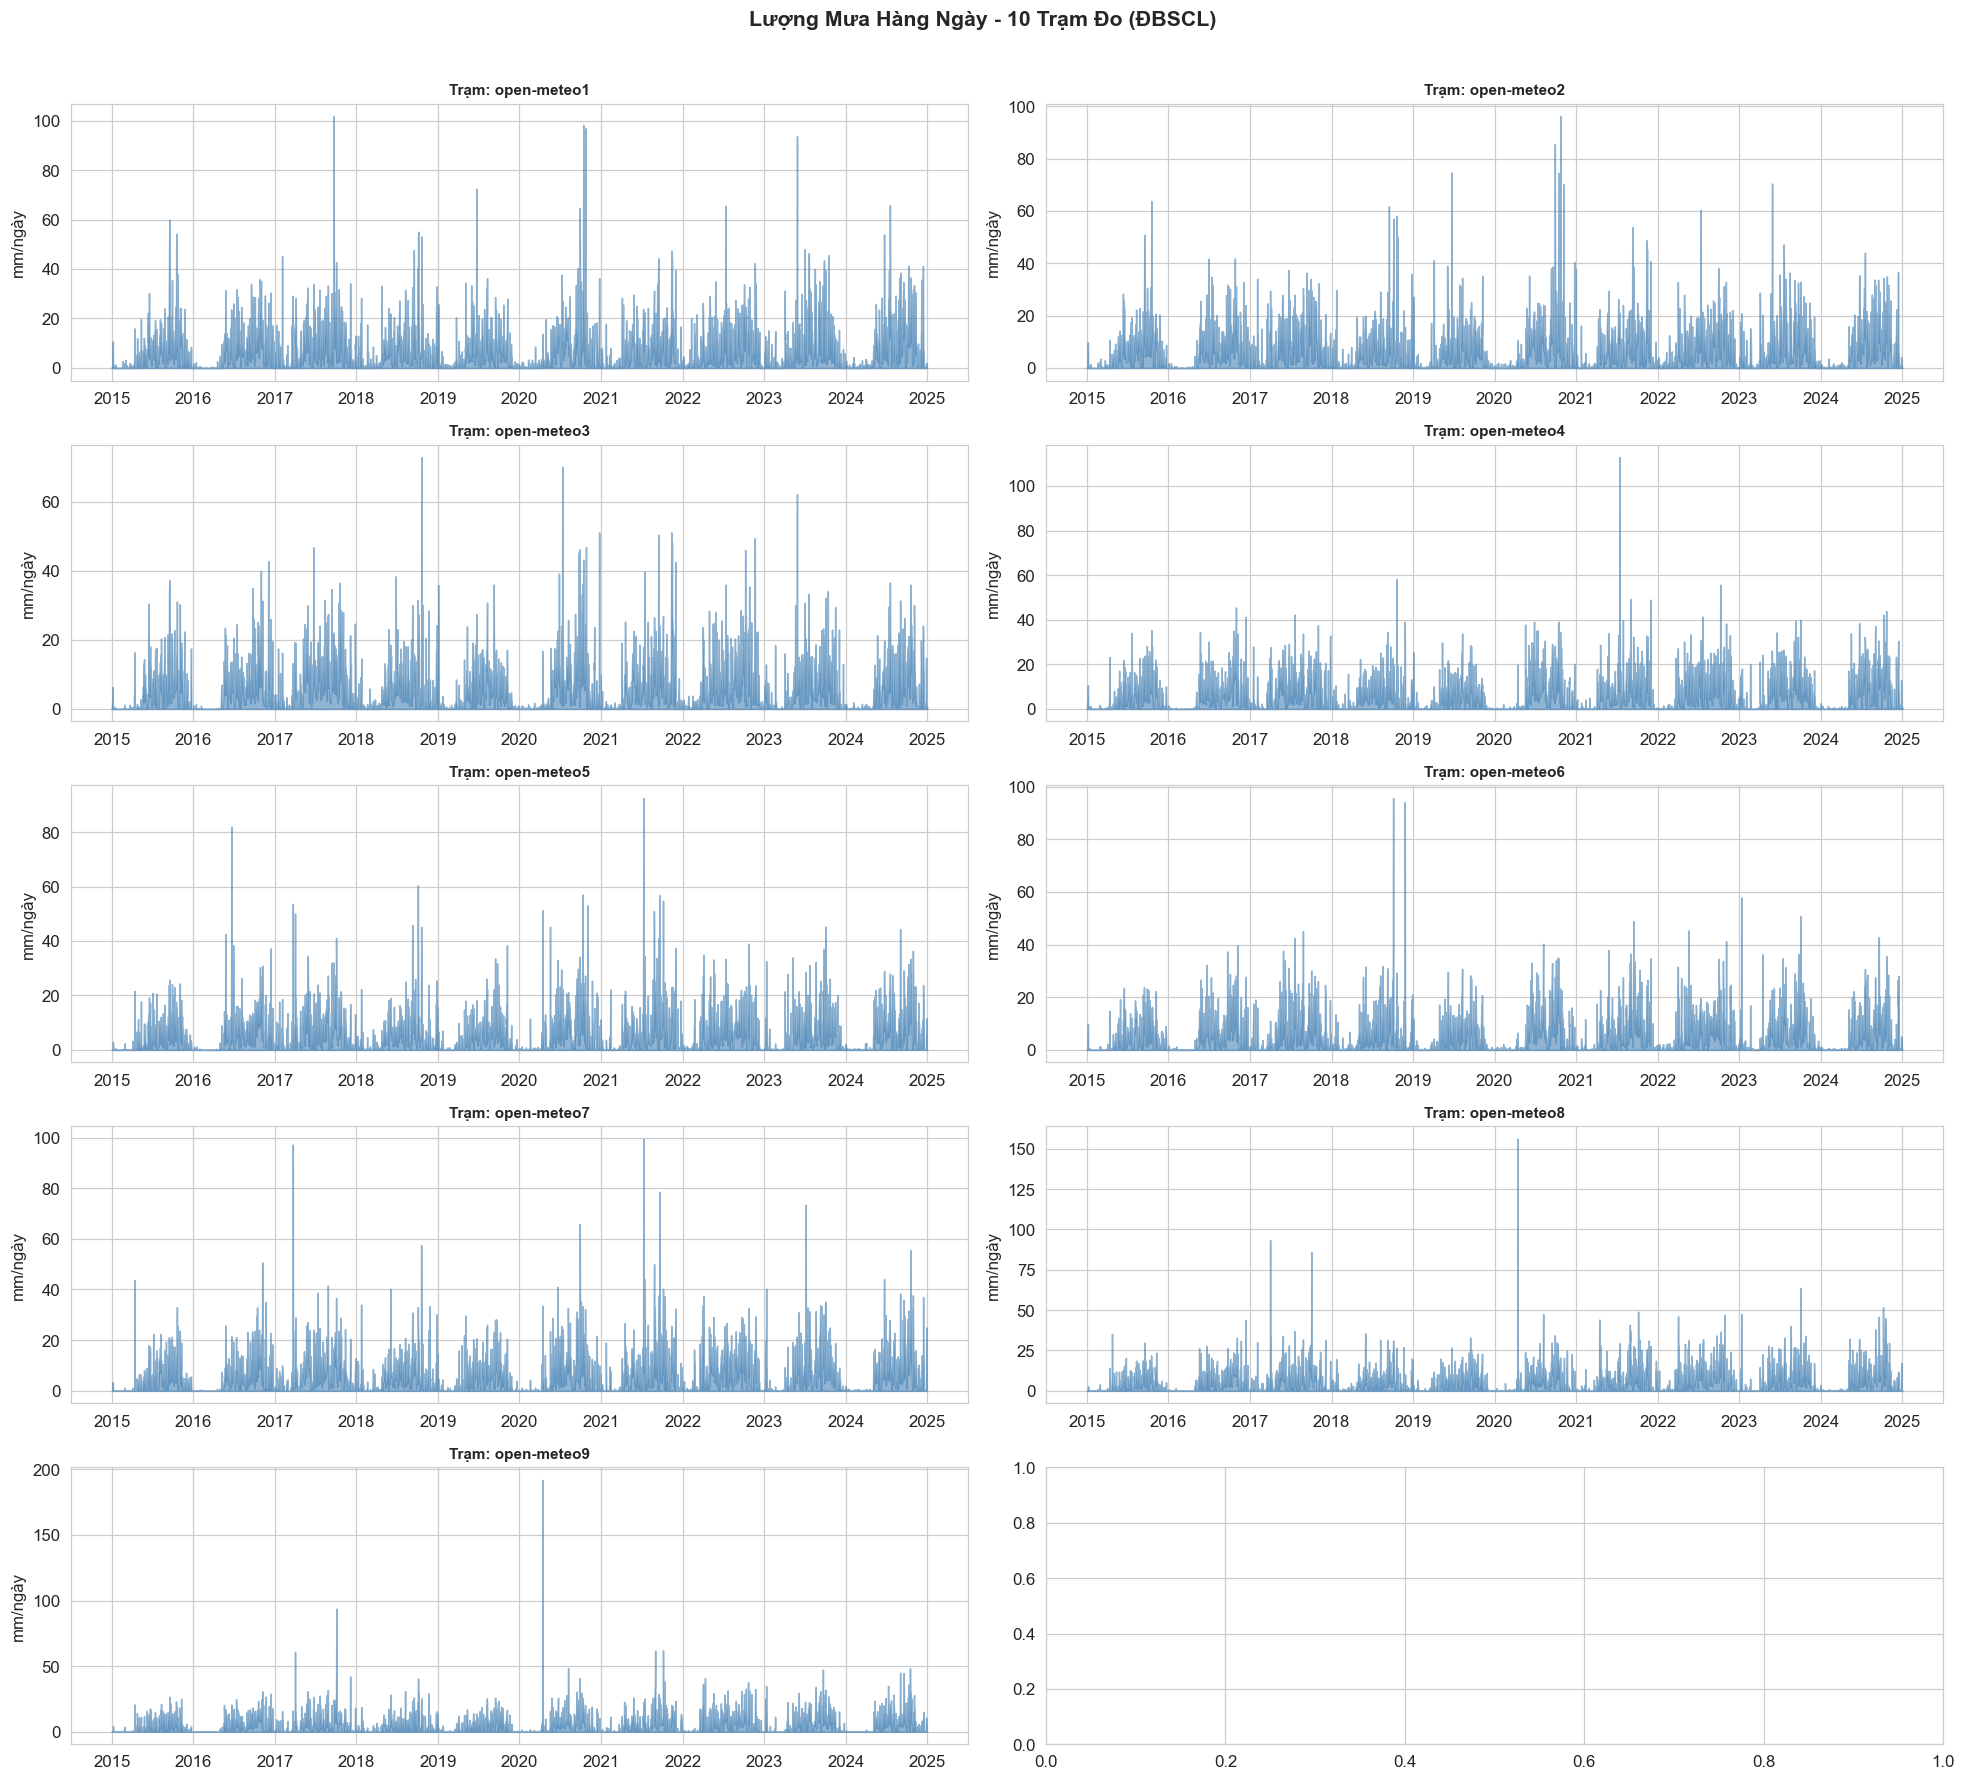

In [28]:
# ── 3.1 Tổng quan lượng mưa tất cả trạm ──────────────────────
fig, axes = plt.subplots(5, 2, figsize=(18, 16), sharex=False)
axes = axes.flatten()

for i, (name, df) in enumerate(stations_clean.items()):
    ax = axes[i]
    ax.fill_between(df.index, df['precipitation'], alpha=0.6, color='steelblue')
    ax.set_title(f'Trạm: {name}', fontsize=10, fontweight='bold')
    ax.set_ylabel('mm/ngày')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Lượng Mưa Hàng Ngày - 10 Trạm Đo (ĐBSCL)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_all_stations_rainfall.png', bbox_inches='tight')
plt.show()

In [29]:
# ── 3.2 Thống kê mô tả tổng hợp ──────────────────────────────
summary_rows = []
for name, df in stations_clean.items():
    r = df['precipitation']
    summary_rows.append({
        'Trạm': name,
        'Số ngày': len(r),
        'TB (mm)': round(r.mean(), 2),
        'Std': round(r.std(), 2),
        'Max (mm)': round(r.max(), 2),
        'Tổng (mm)': round(r.sum(), 1),
        'Ngày mưa (>0.1mm)': int((r > 0.1).sum()),
        'Tỷ lệ ngày mưa (%)': round((r > 0.1).mean() * 100, 1),
    })
summary_df = pd.DataFrame(summary_rows).set_index('Trạm')
print('📋 Thống kê mô tả lượng mưa tại 10 trạm:')
display(summary_df)

📋 Thống kê mô tả lượng mưa tại 10 trạm:


,Số ngày,TB (mm),Std,Max (mm),Tổng (mm),Ngày mưa (>0.1mm),Tỷ lệ ngày mưa (%)
Trạm,,,,,,,
open-meteo1,3653,7.28,9.21,101.8,26603.1,3044,83.3
open-meteo2,3653,6.86,8.62,96.2,25058.8,2975,81.4
open-meteo3,3653,5.86,7.48,72.9,21408.3,2841,77.8
open-meteo4,3653,6.37,8.05,112.9,23261.1,2682,73.4
open-meteo5,3653,5.75,7.67,92.5,20996.6,2765,75.7
open-meteo6,3653,5.55,7.60,95.7,20288.0,2762,75.6
open-meteo7,3653,5.93,8.01,99.4,21653.6,2711,74.2
open-meteo8,3653,5.71,8.13,156.0,20869.6,2704,74.0
open-meteo9,3653,5.33,7.87,191.9,19470.8,2683,73.4


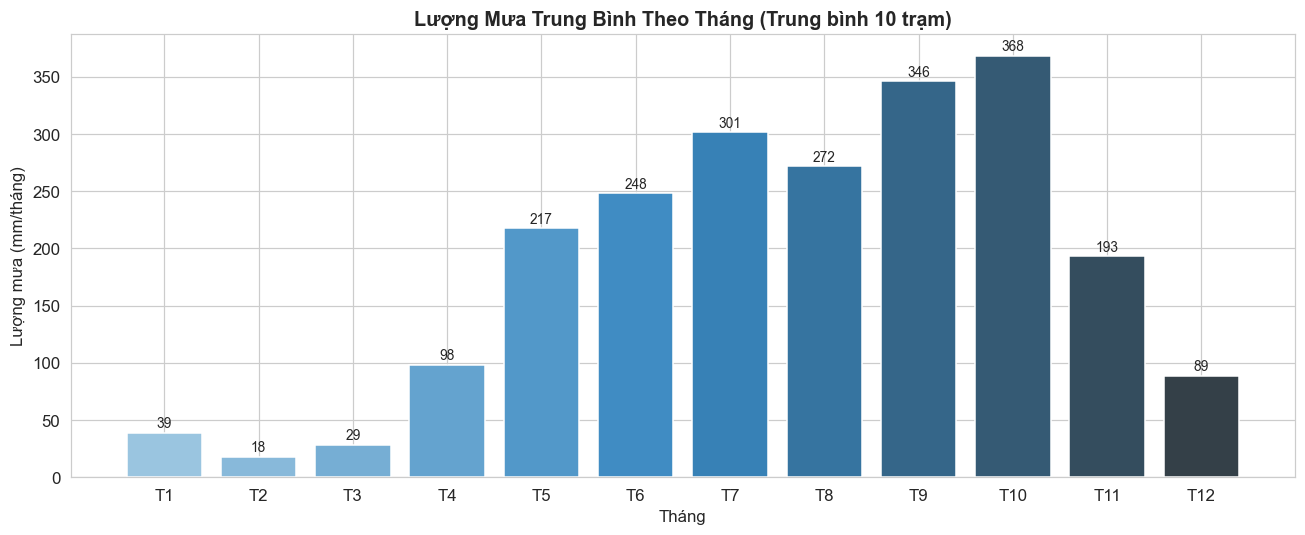

📌 Mùa mưa rõ ràng từ tháng 5 đến tháng 11 - cần dùng SARIMA!


In [30]:
# ── 3.3 Phân tích mùa vụ theo tháng (trung bình tất cả trạm) ──
all_monthly = []
for name, df in stations_clean.items():
    monthly = df['precipitation'].resample('ME').sum()
    monthly_avg = monthly.groupby(monthly.index.month).mean()
    all_monthly.append(monthly_avg)

monthly_mean = pd.concat(all_monthly, axis=1).mean(axis=1)
month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(month_labels, monthly_mean.values, color=sns.color_palette('Blues_d', 12))
ax.set_title('Lượng Mưa Trung Bình Theo Tháng (Trung bình 10 trạm)', fontsize=13, fontweight='bold')
ax.set_ylabel('Lượng mưa (mm/tháng)')
ax.set_xlabel('Tháng')
for bar, val in zip(bars, monthly_mean.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('02_monthly_seasonality.png', bbox_inches='tight')
plt.show()
print('📌 Mùa mưa rõ ràng từ tháng 5 đến tháng 11 - cần dùng SARIMA!')

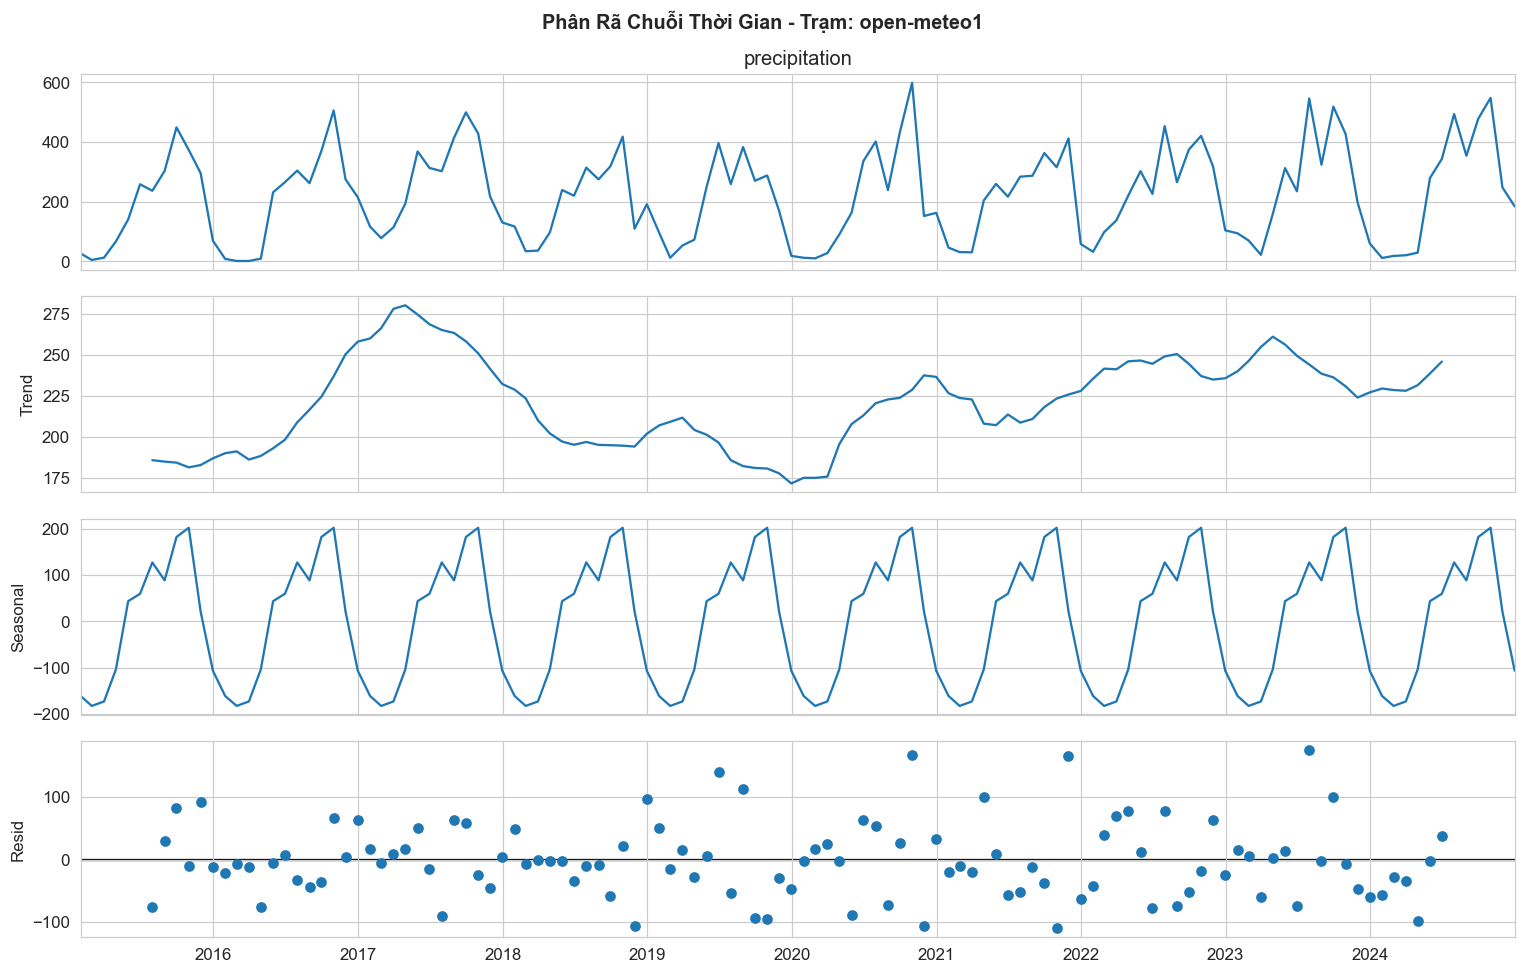

In [31]:
# ── 3.4 Phân rã chuỗi thời gian (seasonal decompose) ──────────
# Dùng trạm đầu tiên làm ví dụ
sample_df = stations_clean[sample_name]

# Tổng hợp tháng để decompose rõ hơn
monthly_series = sample_df['precipitation'].resample('ME').sum()

decomp = seasonal_decompose(monthly_series, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(14, 9)
fig.suptitle(f'Phân Rã Chuỗi Thời Gian - Trạm: {sample_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_seasonal_decompose.png', bbox_inches='tight')
plt.show()

## 4. Kiểm định tính dừng (Stationarity Tests)

In [32]:
def adf_test(series: pd.Series, name: str = '') -> dict:
    """ADF test - H0: có nghiệm đơn vị (không dừng)."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Trạm': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Crit 1%': round(result[4]['1%'], 4),
        'Crit 5%': round(result[4]['5%'], 4),
        'Dừng (p<0.05)': '✅ Có' if result[1] < 0.05 else '❌ Không'
    }


adf_results = []
for name, df in stations_clean.items():
    series = df['precipitation'].resample('ME').sum()
    adf_results.append(adf_test(series, name))

adf_df = pd.DataFrame(adf_results).set_index('Trạm')
print('📊 Kết quả kiểm định ADF (chuỗi tháng) cho 10 trạm:')
display(adf_df)
print('\n💡 Nếu chuỗi không dừng → cần lấy sai phân bậc 1 (d=1) khi dùng ARIMA.')

📊 Kết quả kiểm định ADF (chuỗi tháng) cho 10 trạm:


,ADF Statistic,p-value,Crit 1%,Crit 5%,Dừng (p<0.05)
Trạm,,,,,
open-meteo1,-1.8290,0.3662,-3.4924,-2.8887,❌ Không
open-meteo2,-2.7226,0.0702,-3.4936,-2.8892,❌ Không
open-meteo3,-2.1825,0.2127,-3.4936,-2.8892,❌ Không
open-meteo4,-1.8445,0.3586,-3.4936,-2.8892,❌ Không
open-meteo5,-2.0405,0.2691,-3.4924,-2.8887,❌ Không
open-meteo6,-2.2942,0.1738,-3.4924,-2.8887,❌ Không
open-meteo7,-1.9431,0.3120,-3.4924,-2.8887,❌ Không
open-meteo8,-1.8614,0.3504,-3.4924,-2.8887,❌ Không
open-meteo9,-1.7520,0.4045,-3.4924,-2.8887,❌ Không



💡 Nếu chuỗi không dừng → cần lấy sai phân bậc 1 (d=1) khi dùng ARIMA.


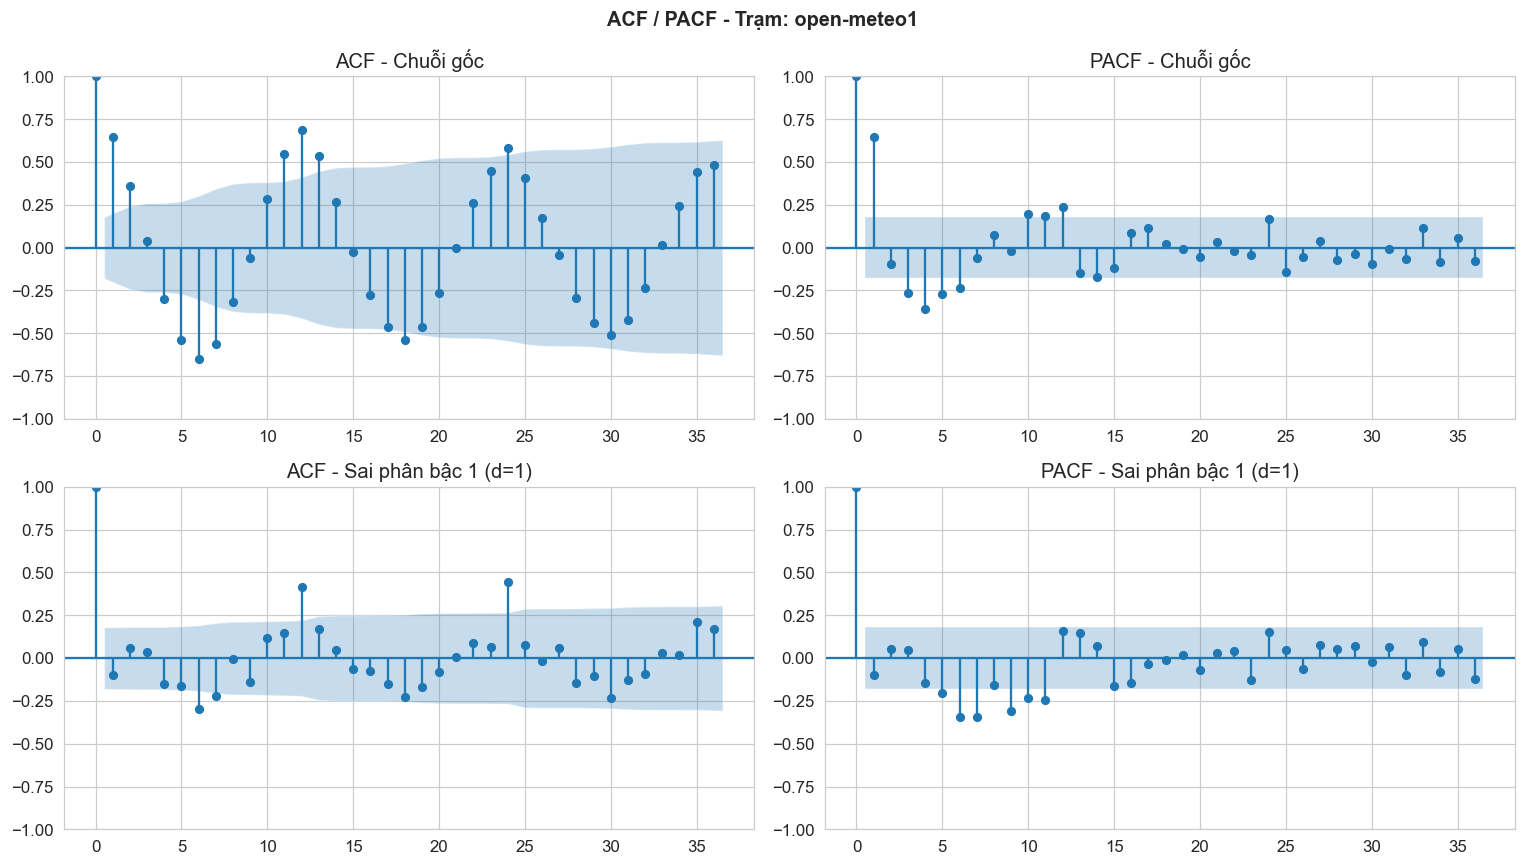

In [33]:
# ── Vẽ ACF / PACF cho trạm mẫu ───────────────────────────────
monthly_sample = stations_clean[sample_name]['precipitation'].resample('ME').sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Chuỗi gốc
plot_acf(monthly_sample, lags=36, ax=axes[0,0], title='ACF - Chuỗi gốc')
plot_pacf(monthly_sample, lags=36, ax=axes[0,1], title='PACF - Chuỗi gốc', method='ywm')

# Chuỗi sai phân bậc 1
diff1 = monthly_sample.diff().dropna()
plot_acf(diff1, lags=36, ax=axes[1,0], title='ACF - Sai phân bậc 1 (d=1)')
plot_pacf(diff1, lags=36, ax=axes[1,1], title='PACF - Sai phân bậc 1 (d=1)', method='ywm')

plt.suptitle(f'ACF / PACF - Trạm: {sample_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_acf_pacf.png', bbox_inches='tight')
plt.show()

## 5. Xây dựng mô hình ARIMA

In [34]:
def train_test_split_ts(series: pd.Series, test_ratio: float = 0.2):
    split = int(len(series) * (1 - test_ratio))
    return series.iloc[:split], series.iloc[split:]


def evaluate_forecast(actual, predicted, model_name: str) -> dict:
    n = min(len(actual), len(predicted))
    actual, predicted = actual.values[:n], np.array(predicted)[:n]
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # MAPE tránh chia cho 0
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100 if mask.any() else np.nan
    return {'Model': model_name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'MAPE (%)': round(mape, 2)}


print('⚙️  Hàm hỗ trợ đã được định nghĩa.')

⚙️  Hàm hỗ trợ đã được định nghĩa.


In [35]:
# ── 5.1 Auto ARIMA với pmdarima (tìm p,d,q tốt nhất tự động) ──
arima_models  = {}   # {station_name: fitted_model}
arima_results = []   # [{station, MAE, RMSE, ...}]

print('🔧 Huấn luyện ARIMA cho 10 trạm (dữ liệu tháng)...\n')

for name in tqdm(station_names, desc='ARIMA'):
    series = stations_clean[name]['precipitation'].resample('ME').sum()
    train, test = train_test_split_ts(series, TEST_RATIO)

    try:
        model = pm.auto_arima(
            train,
            start_p=0, max_p=4,
            start_q=0, max_q=4,
            d=None,           # tự động chọn d qua ADF
            seasonal=False,   # ARIMA thuần (không mùa vụ)
            information_criterion='aic',
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
        )
        forecast = model.predict(n_periods=len(test))
        forecast = np.clip(forecast, 0, None)  # lượng mưa ≥ 0
        metrics = evaluate_forecast(test, forecast, f'ARIMA{model.order}')
        metrics['Trạm'] = name
        metrics['Order'] = str(model.order)
        metrics['AIC'] = round(model.aic(), 2)
        arima_results.append(metrics)
        arima_models[name] = model
    except Exception as e:
        print(f'  ⚠️  {name}: lỗi ARIMA - {e}')

arima_df = pd.DataFrame(arima_results).set_index('Trạm')
print('\n📊 Kết quả ARIMA:')
display(arima_df)

🔧 Huấn luyện ARIMA cho 10 trạm (dữ liệu tháng)...



ARIMA: 100%|██████████| 9/9 [00:10<00:00,  1.11s/it]


📊 Kết quả ARIMA:


,Model,MAE,RMSE,MAPE (%),Order,AIC
Trạm,,,,,,
open-meteo1,"ARIMA(4, 0, 1)",107.191,134.544,151.79,"(4, 0, 1)",1159.30
open-meteo2,"ARIMA(4, 0, 1)",82.472,95.259,202.51,"(4, 0, 1)",1151.25
open-meteo3,"ARIMA(1, 0, 0)",108.299,126.701,803.27,"(1, 0, 0)",1164.24
open-meteo4,"ARIMA(1, 0, 0)",144.872,167.245,898.72,"(1, 0, 0)",1173.74
open-meteo5,"ARIMA(2, 0, 2)",72.518,90.416,379.35,"(2, 0, 2)",1120.25
open-meteo6,"ARIMA(4, 0, 1)",81.213,96.880,523.96,"(4, 0, 1)",1131.23
open-meteo7,"ARIMA(4, 0, 1)",86.511,106.712,520.25,"(4, 0, 1)",1120.15
open-meteo8,"ARIMA(2, 0, 1)",112.790,140.334,573.11,"(2, 0, 1)",1129.15
open-meteo9,"ARIMA(2, 0, 1)",103.681,128.468,603.19,"(2, 0, 1)",1107.56


## 6. Xây dựng mô hình SARIMA

In [36]:
# ── 6.1 Auto SARIMA (bao gồm thành phần mùa vụ m=12) ──────────
sarima_models  = {}
sarima_results = []

print('🔧 Huấn luyện SARIMA cho 10 trạm (dữ liệu tháng, m=12)...\n')

for name in tqdm(station_names, desc='SARIMA'):
    series = stations_clean[name]['precipitation'].resample('ME').sum()
    train, test = train_test_split_ts(series, TEST_RATIO)

    try:
        model = pm.auto_arima(
            train,
            start_p=0, max_p=3,
            start_q=0, max_q=3,
            d=None,
            seasonal=True,
            m=12,             # chu kỳ mùa vụ 12 tháng
            start_P=0, max_P=2,
            start_Q=0, max_Q=2,
            D=None,
            information_criterion='aic',
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False,
        )
        forecast = model.predict(n_periods=len(test))
        forecast = np.clip(forecast, 0, None)
        metrics = evaluate_forecast(test, forecast, 'SARIMA')
        metrics['Trạm'] = name
        metrics['Order'] = str(model.order)
        metrics['Seasonal Order'] = str(model.seasonal_order)
        metrics['AIC'] = round(model.aic(), 2)
        sarima_results.append(metrics)
        sarima_models[name] = model
    except Exception as e:
        print(f'  ⚠️  {name}: lỗi SARIMA - {e}')

sarima_df = pd.DataFrame(sarima_results).set_index('Trạm')
print('\n📊 Kết quả SARIMA:')
display(sarima_df)

🔧 Huấn luyện SARIMA cho 10 trạm (dữ liệu tháng, m=12)...



SARIMA: 100%|██████████| 9/9 [01:01<00:00,  6.78s/it]


📊 Kết quả SARIMA:


,Model,MAE,RMSE,MAPE (%),Order,Seasonal Order,AIC
Trạm,,,,,,,
open-meteo1,SARIMA,99.852,122.425,143.42,"(1, 0, 0)","(2, 0, 1, 12)",1136.53
open-meteo2,SARIMA,84.396,101.713,265.95,"(1, 0, 0)","(2, 0, 1, 12)",1123.01
open-meteo3,SARIMA,46.366,56.379,280.11,"(1, 0, 0)","(1, 0, 1, 12)",1129.69
open-meteo4,SARIMA,71.049,83.681,359.49,"(1, 0, 0)","(1, 0, 1, 12)",1134.97
open-meteo5,SARIMA,53.576,66.764,310.41,"(1, 0, 1)","(1, 0, 1, 12)",1104.63
open-meteo6,SARIMA,76.565,86.417,563.40,"(1, 0, 0)","(2, 0, 0, 12)",1120.83
open-meteo7,SARIMA,60.940,75.322,523.86,"(1, 0, 1)","(1, 0, 1, 12)",1097.48
open-meteo8,SARIMA,61.082,77.491,412.54,"(1, 0, 0)","(1, 0, 1, 12)",1092.28
open-meteo9,SARIMA,62.182,79.449,368.35,"(1, 0, 0)","(1, 0, 1, 12)",1075.93


## 7. So sánh ARIMA vs SARIMA

In [37]:
# ── 7.1 Bảng so sánh tổng hợp ─────────────────────────────────
compare_rows = []
for name in station_names:
    a = arima_df.loc[name] if name in arima_df.index else None
    s = sarima_df.loc[name] if name in sarima_df.index else None
    if a is not None and s is not None:
        winner = 'SARIMA ✅' if s['RMSE'] < a['RMSE'] else 'ARIMA ✅'
        compare_rows.append({
            'Trạm': name,
            'ARIMA MAE': a['MAE'], 'ARIMA RMSE': a['RMSE'],
            'SARIMA MAE': s['MAE'], 'SARIMA RMSE': s['RMSE'],
            'ΔRMSE': round(float(a['RMSE']) - float(s['RMSE']), 3),
            'Mô hình tốt hơn': winner,
        })

compare_df = pd.DataFrame(compare_rows).set_index('Trạm')
print('📊 So sánh ARIMA vs SARIMA:')
display(compare_df)

n_sarima_wins = (compare_df['ΔRMSE'] > 0).sum()
print(f'\n🏆 SARIMA tốt hơn ARIMA tại {n_sarima_wins}/{len(compare_df)} trạm.')

📊 So sánh ARIMA vs SARIMA:


,ARIMA MAE,ARIMA RMSE,SARIMA MAE,SARIMA RMSE,ΔRMSE,Mô hình tốt hơn
Trạm,,,,,,
open-meteo1,107.191,134.544,99.852,122.425,12.119,SARIMA ✅
open-meteo2,82.472,95.259,84.396,101.713,-6.454,ARIMA ✅
open-meteo3,108.299,126.701,46.366,56.379,70.322,SARIMA ✅
open-meteo4,144.872,167.245,71.049,83.681,83.564,SARIMA ✅
open-meteo5,72.518,90.416,53.576,66.764,23.652,SARIMA ✅
open-meteo6,81.213,96.880,76.565,86.417,10.463,SARIMA ✅
open-meteo7,86.511,106.712,60.940,75.322,31.390,SARIMA ✅
open-meteo8,112.790,140.334,61.082,77.491,62.843,SARIMA ✅
open-meteo9,103.681,128.468,62.182,79.449,49.019,SARIMA ✅



🏆 SARIMA tốt hơn ARIMA tại 8/9 trạm.


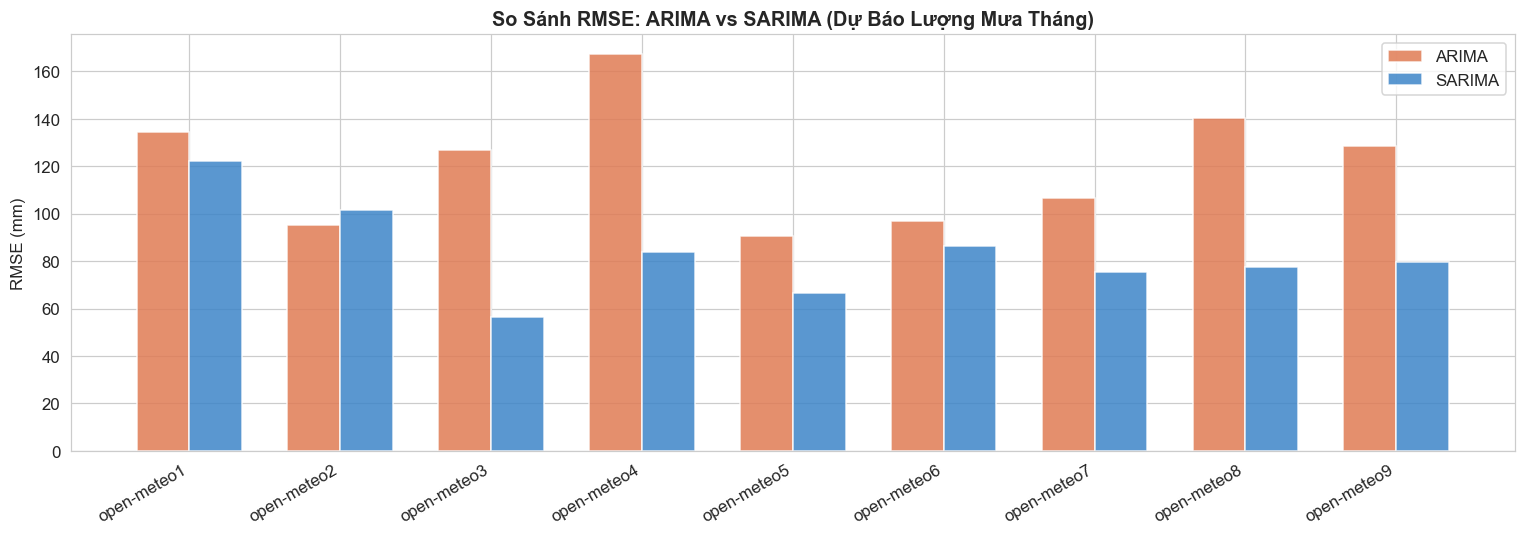

In [38]:
# ── 7.2 Biểu đồ so sánh RMSE ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(compare_df))
w = 0.35
b1 = ax.bar(x - w/2, compare_df['ARIMA RMSE'],  width=w, label='ARIMA',  color='#e07b54', alpha=0.85)
b2 = ax.bar(x + w/2, compare_df['SARIMA RMSE'], width=w, label='SARIMA', color='#3d85c8', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=30, ha='right')
ax.set_ylabel('RMSE (mm)')
ax.set_title('So Sánh RMSE: ARIMA vs SARIMA (Dự Báo Lượng Mưa Tháng)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('05_arima_vs_sarima_rmse.png', bbox_inches='tight')
plt.show()

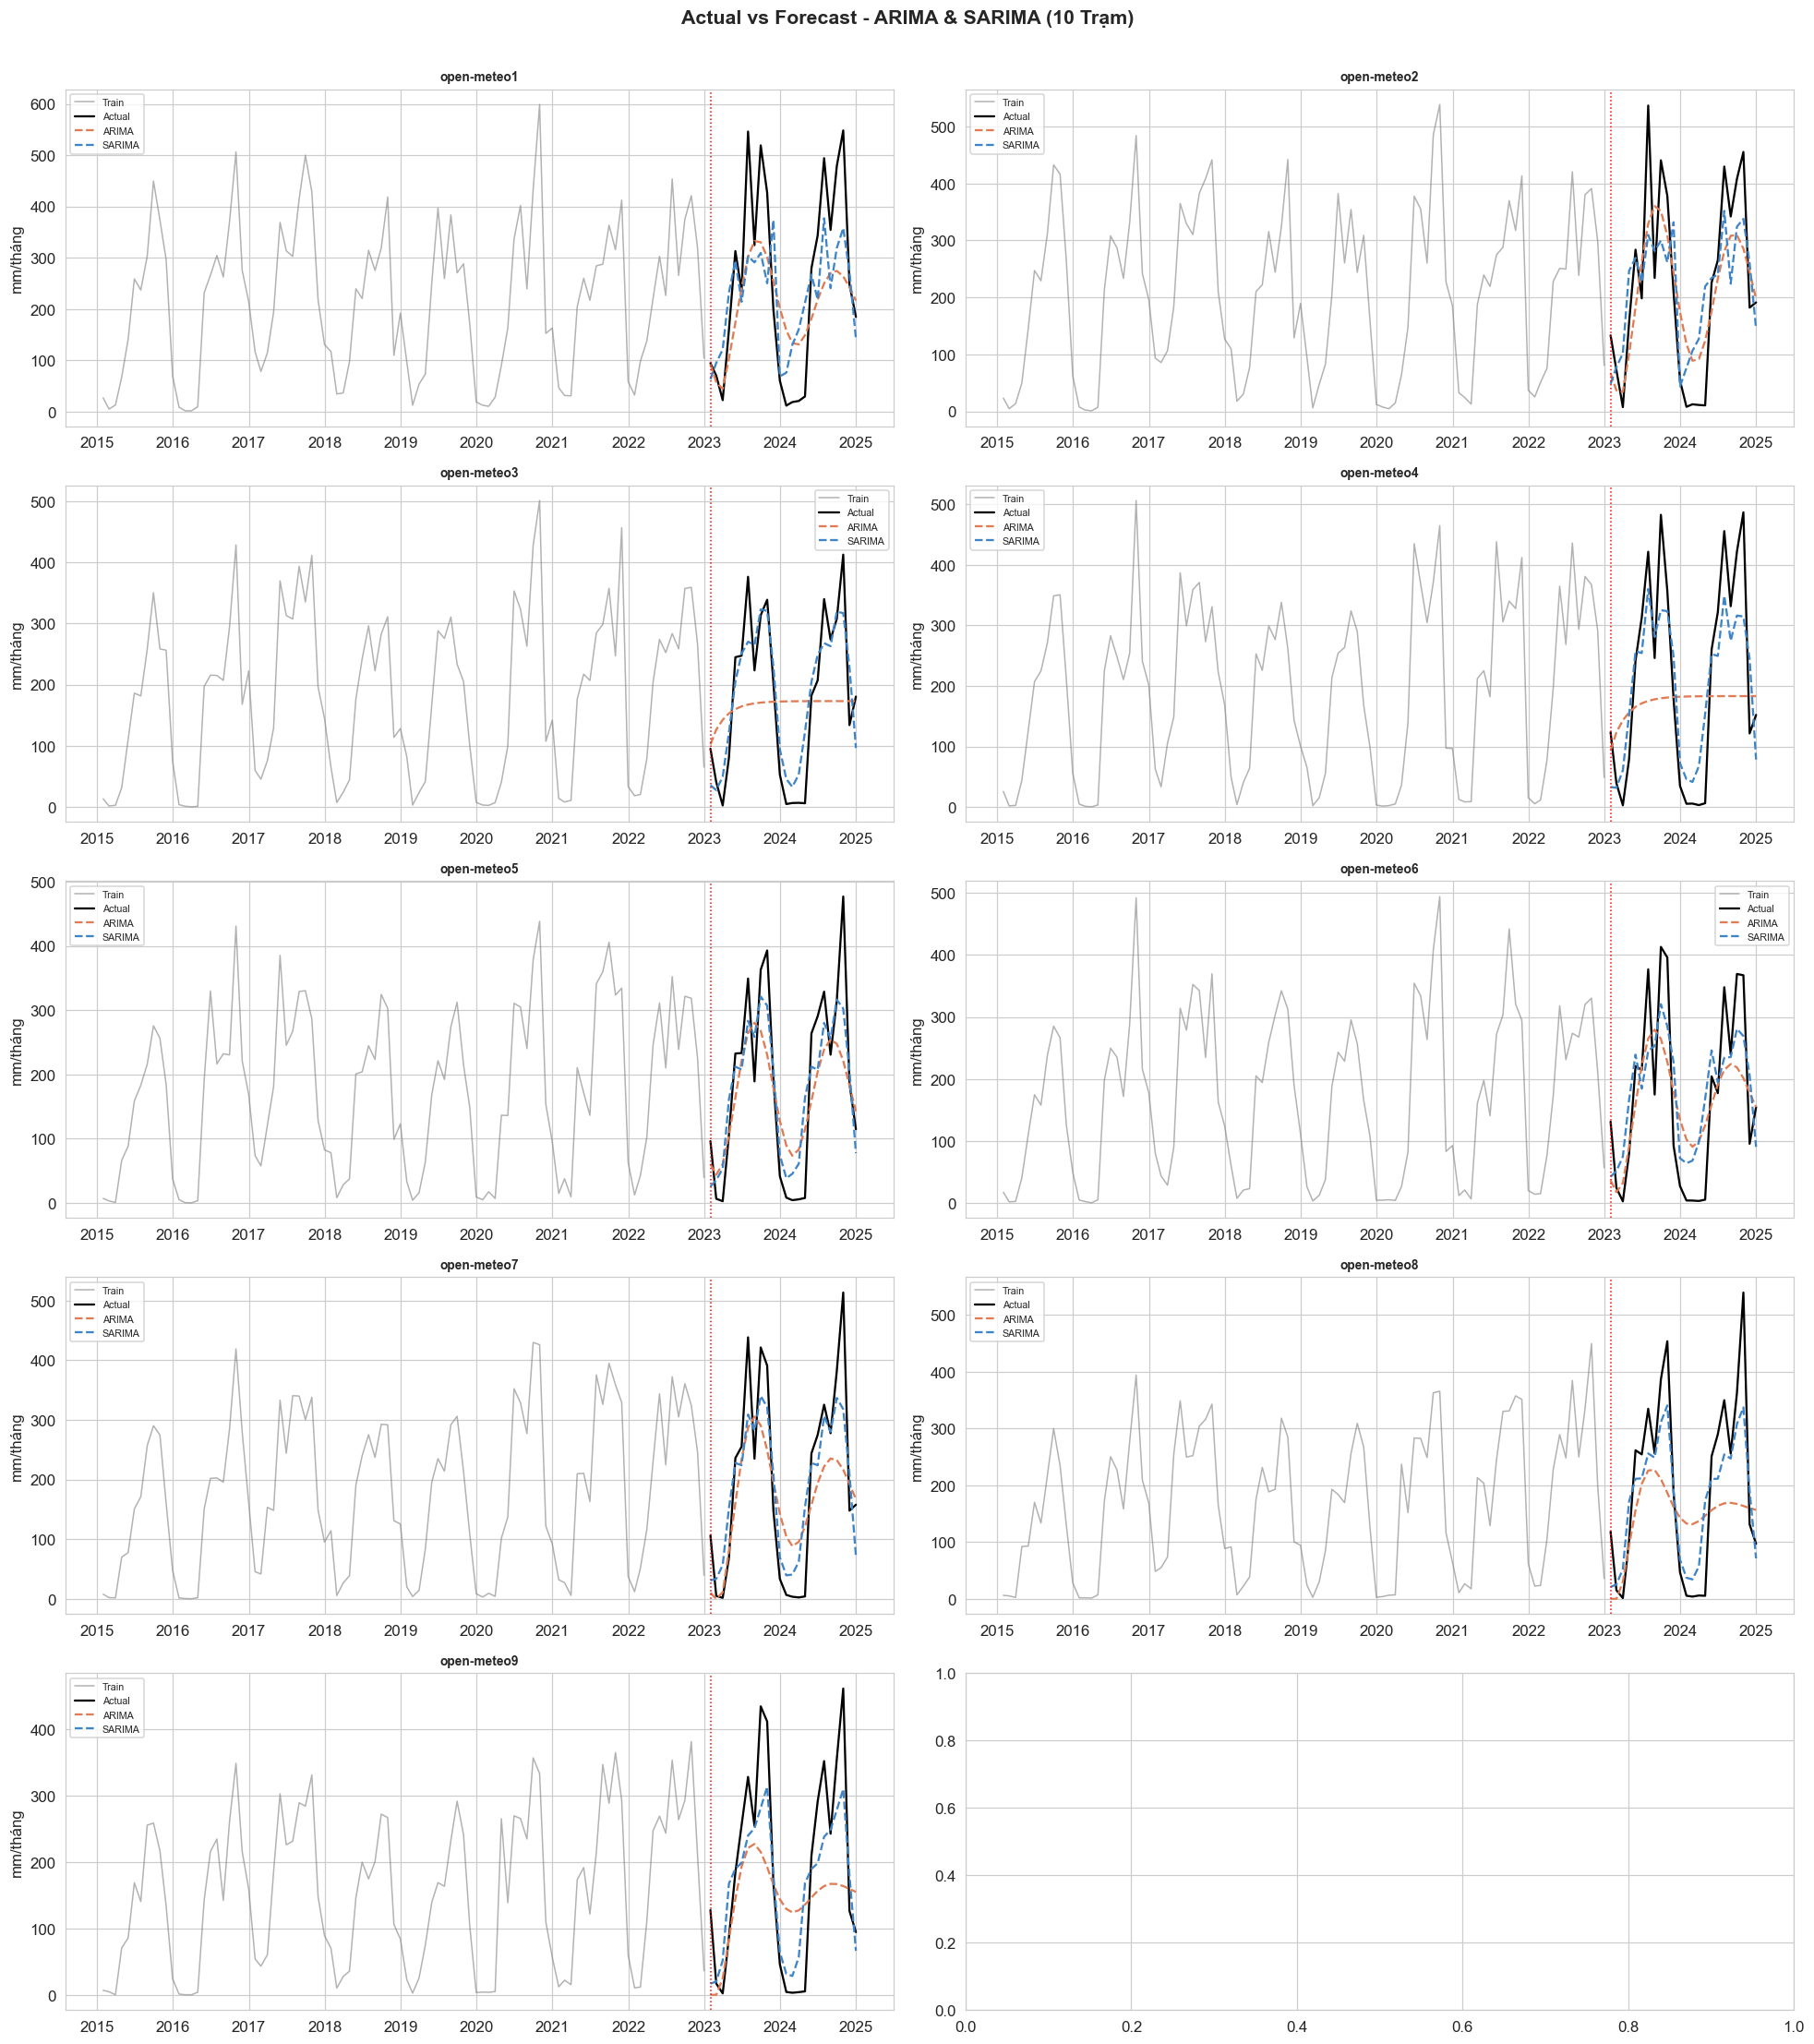

In [39]:
# ── 7.3 Biểu đồ Actual vs Forecast cho từng trạm ──────────────
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, name in enumerate(station_names[:10]):
    ax = axes[i]
    series = stations_clean[name]['precipitation'].resample('ME').sum()
    train, test = train_test_split_ts(series, TEST_RATIO)

    ax.plot(train.index, train.values, color='gray', linewidth=1, alpha=0.6, label='Train')
    ax.plot(test.index,  test.values,  color='black', linewidth=1.5, label='Actual')

    if name in arima_models:
        fc_a = np.clip(arima_models[name].predict(len(test)), 0, None)
        ax.plot(test.index, fc_a, '--', color='#e07b54', linewidth=1.5, label='ARIMA')

    if name in sarima_models:
        fc_s = np.clip(sarima_models[name].predict(len(test)), 0, None)
        ax.plot(test.index, fc_s, '--', color='#3d85c8', linewidth=1.5, label='SARIMA')

    ax.axvline(test.index[0], color='red', linestyle=':', linewidth=1)
    ax.set_title(f'{name}', fontsize=9, fontweight='bold')
    ax.set_ylabel('mm/tháng')
    ax.legend(fontsize=7)

plt.suptitle('Actual vs Forecast - ARIMA & SARIMA (10 Trạm)', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('06_forecast_comparison.png', bbox_inches='tight')
plt.show()

## 8. Kiểm tra phần dư (Residual Diagnostics)

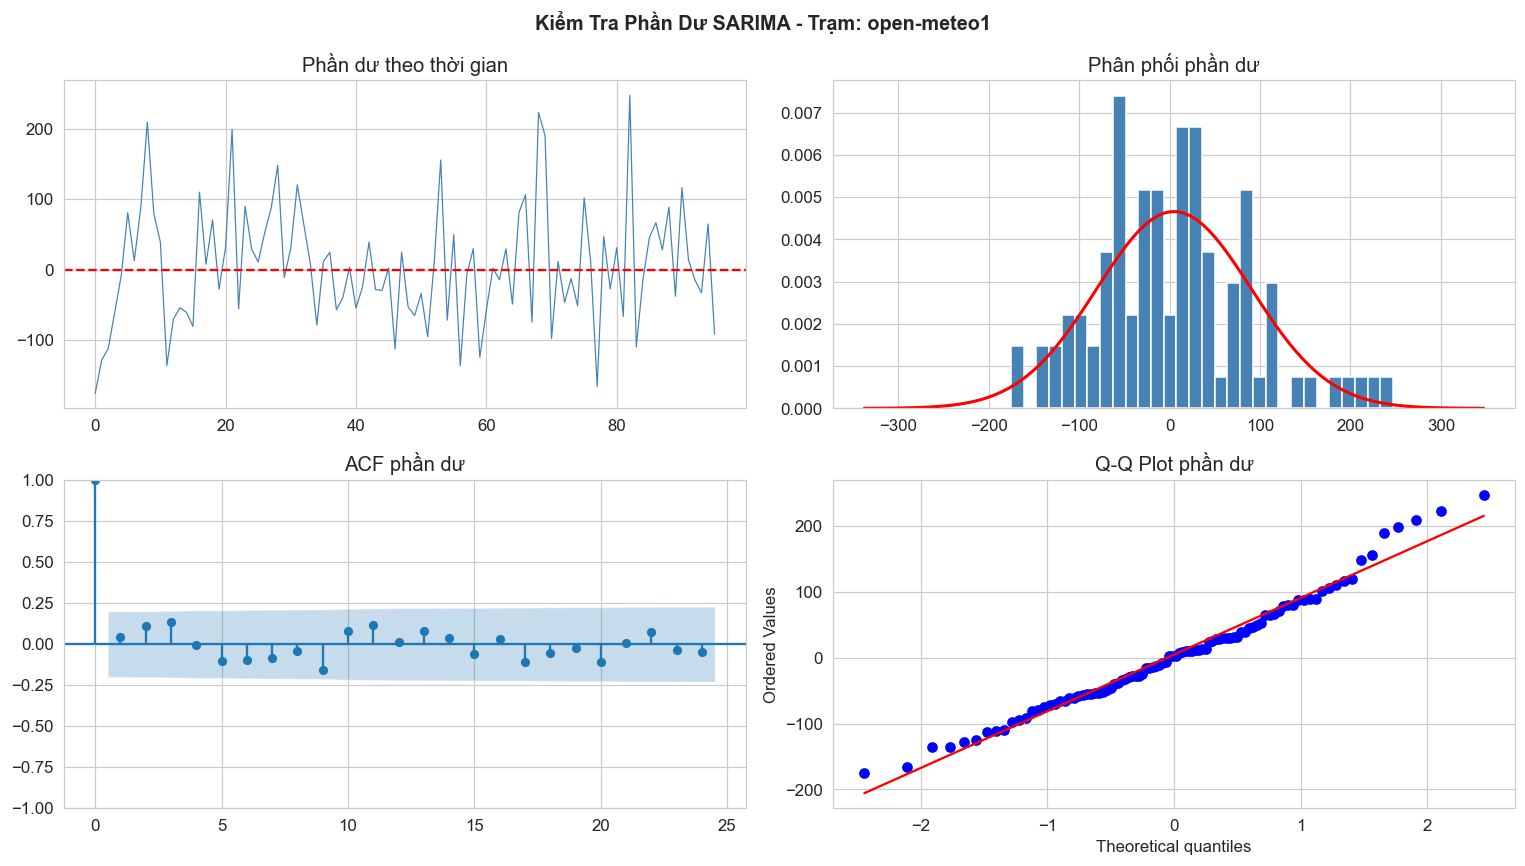

🔬 Kiểm định Ljung-Box (H0: phần dư là white noise):


,lb_stat,lb_pvalue
10,9.632230,0.473329
20,15.793161,0.729370


✅ p-value > 0.05 → phần dư không có tự tương quan → mô hình phù hợp.


In [40]:
# Dùng mô hình SARIMA của trạm mẫu để kiểm tra residual
if sample_name in sarima_models:
    model = sarima_models[sample_name]
    residuals = pd.Series(model.resid())

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Residuals theo thời gian
    axes[0,0].plot(residuals.values, color='steelblue', linewidth=0.8)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title('Phần dư theo thời gian')

    # Histogram
    axes[0,1].hist(residuals, bins=30, color='steelblue', edgecolor='white', density=True)
    mu, std = residuals.mean(), residuals.std()
    x = np.linspace(mu - 4*std, mu + 4*std, 100)
    from scipy.stats import norm
    axes[0,1].plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2)
    axes[0,1].set_title('Phân phối phần dư')

    # ACF phần dư
    plot_acf(residuals, lags=24, ax=axes[1,0], title='ACF phần dư')

    # Q-Q plot
    from scipy.stats import probplot
    probplot(residuals, dist='norm', plot=axes[1,1])
    axes[1,1].set_title('Q-Q Plot phần dư')

    plt.suptitle(f'Kiểm Tra Phần Dư SARIMA - Trạm: {sample_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('07_residual_diagnostics.png', bbox_inches='tight')
    plt.show()

    # Ljung-Box test
    lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
    print('🔬 Kiểm định Ljung-Box (H0: phần dư là white noise):')
    display(lb)
    print('✅ p-value > 0.05 → phần dư không có tự tương quan → mô hình phù hợp.')

## 9. Dự báo tương lai

In [41]:
# ── 9.1 Chọn mô hình tốt nhất cho mỗi trạm và dự báo ─────────
forecast_all = {}

print(f'🔮 Dự báo {FORECAST_STEPS} tháng tới cho 10 trạm...\n')

for name in station_names:
    series = stations_clean[name]['precipitation'].resample('ME').sum()

    # Chọn mô hình tốt hơn theo RMSE
    use_sarima = False
    if name in compare_df.index:
        use_sarima = compare_df.loc[name, 'ΔRMSE'] > 0

    model_choice = sarima_models.get(name) if use_sarima else arima_models.get(name)
    if model_choice is None:
        model_choice = sarima_models.get(name) or arima_models.get(name)

    if model_choice is None:
        continue

    # Retrain trên toàn bộ dữ liệu
    model_full = model_choice.update(series)

    # Dự báo với confidence interval
    fc, conf_int = model_choice.predict(n_periods=FORECAST_STEPS, return_conf_int=True, alpha=0.1)
    fc = np.clip(fc, 0, None)
    conf_int = np.clip(conf_int, 0, None)

    # Tạo index thời gian tương lai
    last_date = series.index[-1]
    future_idx = pd.date_range(last_date, periods=FORECAST_STEPS + 1, freq='ME')[1:]

    forecast_df = pd.DataFrame({
        'forecast': fc,
        'lower_90': conf_int[:, 0],
        'upper_90': conf_int[:, 1],
    }, index=future_idx)
    forecast_all[name] = (series, forecast_df, 'SARIMA' if use_sarima else 'ARIMA')

print('✅ Dự báo hoàn tất!')

🔮 Dự báo 30 tháng tới cho 10 trạm...

✅ Dự báo hoàn tất!


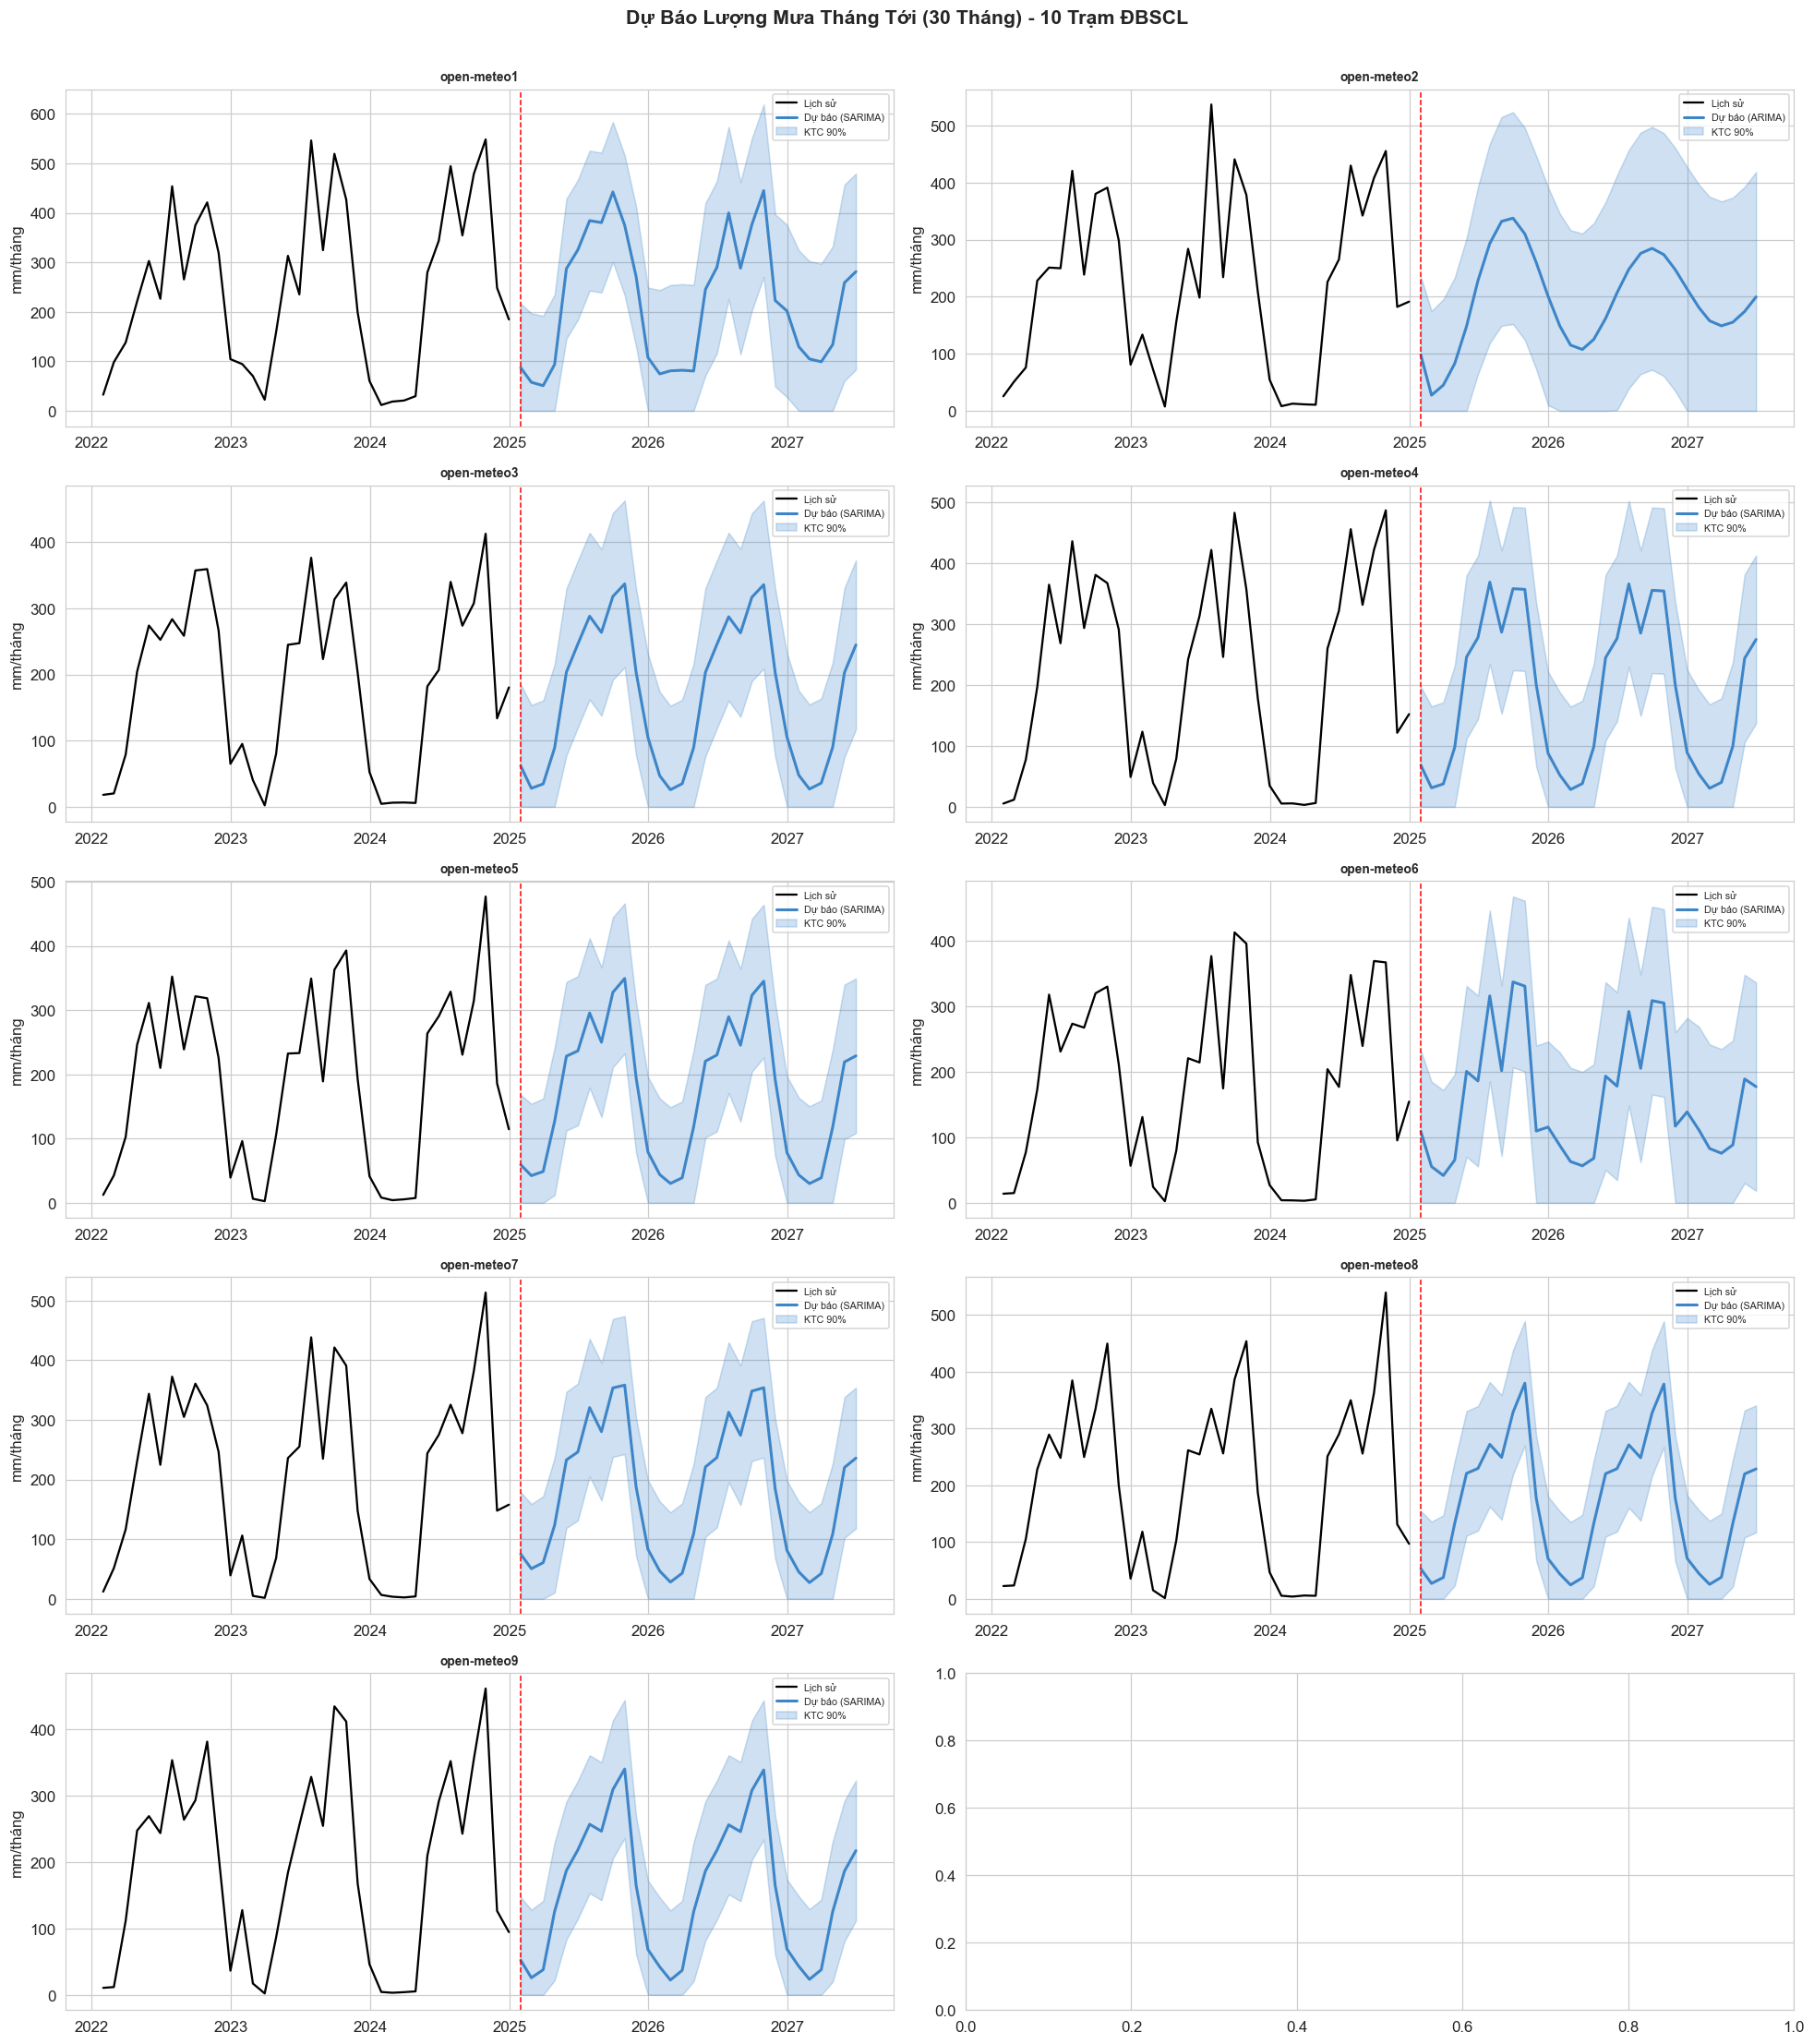

In [42]:
# ── 9.2 Vẽ kết quả dự báo tương lai (10 trạm) ─────────────────
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, (name, (series, fc_df, model_name)) in enumerate(forecast_all.items()):
    ax = axes[i]
    # Chỉ vẽ 36 tháng gần nhất
    history = series.iloc[-36:]
    ax.plot(history.index, history.values, color='black', linewidth=1.5, label='Lịch sử')
    ax.plot(fc_df.index, fc_df['forecast'], color='#3d85c8', linewidth=2, label=f'Dự báo ({model_name})')
    ax.fill_between(fc_df.index, fc_df['lower_90'], fc_df['upper_90'],
                    alpha=0.25, color='#3d85c8', label='KTC 90%')
    ax.axvline(fc_df.index[0], color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{name}', fontsize=9, fontweight='bold')
    ax.set_ylabel('mm/tháng')
    ax.legend(fontsize=7)

plt.suptitle(f'Dự Báo Lượng Mưa Tháng Tới ({FORECAST_STEPS} Tháng) - 10 Trạm ĐBSCL',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('08_future_forecast.png', bbox_inches='tight')
plt.show()

In [43]:
# ── 9.3 Xuất kết quả dự báo ra CSV ────────────────────────────
all_fc_rows = []
for name, (series, fc_df, model_name) in forecast_all.items():
    tmp = fc_df.copy()
    tmp['station'] = name
    tmp['model']   = model_name
    tmp.index.name = 'date'
    all_fc_rows.append(tmp.reset_index())

export_df = pd.concat(all_fc_rows, ignore_index=True)
export_df.to_csv('rainfall_forecast_all_stations.csv', index=False, encoding='utf-8-sig')
print('💾 Đã lưu: rainfall_forecast_all_stations.csv')
display(export_df.head(15))

💾 Đã lưu: rainfall_forecast_all_stations.csv


,date,forecast,lower_90,upper_90,station,model
0,2025-01-31,87.119021,0.000000,216.733067,open-meteo1,SARIMA
1,2025-02-28,57.617537,0.000000,197.096252,open-meteo1,SARIMA
2,2025-03-31,50.766186,0.000000,191.742009,open-meteo1,SARIMA
3,2025-04-30,93.593319,0.000000,234.804489,open-meteo1,SARIMA
4,2025-05-31,287.101053,145.852693,428.349414,open-meteo1,SARIMA
5,2025-06-30,325.062671,183.808429,466.316913,open-meteo1,SARIMA
6,2025-07-31,384.163672,242.908500,525.418843,open-meteo1,SARIMA
7,2025-08-31,380.231509,238.976196,521.486823,open-meteo1,SARIMA
8,2025-09-30,442.040952,300.785647,583.296258,open-meteo1,SARIMA
9,2025-10-31,374.791502,233.536392,516.046612,open-meteo1,SARIMA


## 10. Tổng kết

In [44]:
print('=' * 60)
print('📋 TỔNG KẾT KẾT QUẢ MÔ HÌNH')
print('=' * 60)

print('\n🔹 ARIMA - Trung bình các trạm:')
if not arima_df.empty:
    print(f"   MAE  = {arima_df['MAE'].mean():.3f} mm")
    print(f"   RMSE = {arima_df['RMSE'].mean():.3f} mm")

print('\n🔹 SARIMA - Trung bình các trạm:')
if not sarima_df.empty:
    print(f"   MAE  = {sarima_df['MAE'].mean():.3f} mm")
    print(f"   RMSE = {sarima_df['RMSE'].mean():.3f} mm")

if not compare_df.empty:
    n_wins = (compare_df['ΔRMSE'] > 0).sum()
    print(f'\n🏆 SARIMA tốt hơn tại {n_wins}/{len(compare_df)} trạm.')

print()
print('📁 Các file đã lưu:')
for f in sorted(glob.glob('*.png') + glob.glob('*.csv')):
    print(f'   {f}')

print()
print('💡 Gợi ý cải thiện:')
print('   1. Thêm biến ngoại sinh (SARIMAX): nhiệt độ, độ ẩm, ENSO index')
print('   2. Thử mô hình Prophet của Meta cho dữ liệu có nhiều outlier')
print('   3. LSTM / GRU nếu có đủ dữ liệu (> 5 năm hourly)')
print('   4. Ensemble ARIMA + SARIMA + ML regression')

📋 TỔNG KẾT KẾT QUẢ MÔ HÌNH

🔹 ARIMA - Trung bình các trạm:
   MAE  = 99.950 mm
   RMSE = 120.729 mm

🔹 SARIMA - Trung bình các trạm:
   MAE  = 68.445 mm
   RMSE = 83.293 mm

🏆 SARIMA tốt hơn tại 8/9 trạm.

📁 Các file đã lưu:
   01_all_stations_rainfall.png
   02_monthly_seasonality.png
   03_seasonal_decompose.png
   04_acf_pacf.png
   05_arima_vs_sarima_rmse.png
   06_forecast_comparison.png
   07_residual_diagnostics.png
   08_future_forecast.png
   rainfall_forecast_all_stations.csv

💡 Gợi ý cải thiện:
   1. Thêm biến ngoại sinh (SARIMAX): nhiệt độ, độ ẩm, ENSO index
   2. Thử mô hình Prophet của Meta cho dữ liệu có nhiều outlier
   3. LSTM / GRU nếu có đủ dữ liệu (> 5 năm hourly)
   4. Ensemble ARIMA + SARIMA + ML regression
